In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('../data/cropdata.csv')

In [3]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [21]:
print(df["Crop"].value_counts())

Crop
Coconut      146
Sugarcane     30
Onion          3
Potato         3
Banana         2
Cashewnut      1
Maize          1
Name: count, dtype: int64


In [4]:
df.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield',
       'Avg_Temperature', 'Max_Temperature', 'Min_Temperature'],
      dtype='object')

In [5]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755186,2.410331e+07,4.884835e+04,79.954011,23.831279,33.947314,14.723357
std,6.498099,7.328287e+05,2.630568e+08,816.909592,9.494600e+07,2.132874e+05,878.306194,5.847672,5.732339,6.571713
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000,-5.115000,7.701000,-19.359000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000,23.545000,32.483000,13.535000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000,25.675000,35.826000,15.890000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.389000,26.413000,37.265000,16.983000
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000,28.652000,40.632000,24.972000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 2.0+ MB


In [7]:
# checking the missing values
print(df.isnull().sum())

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64


In [8]:
df = df.drop("Production", axis=1)

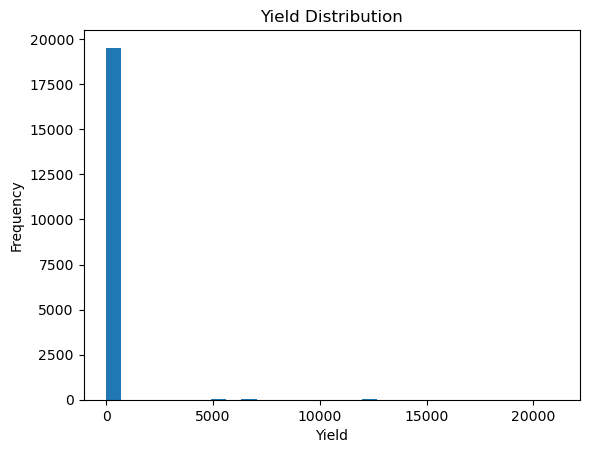

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["Yield"], bins=30)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

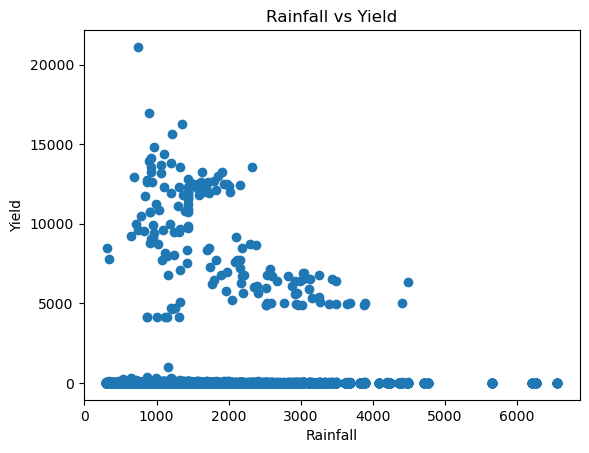

In [10]:
# checking weather rainfall is effect yield
plt.scatter(df["Annual_Rainfall"], df["Yield"])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

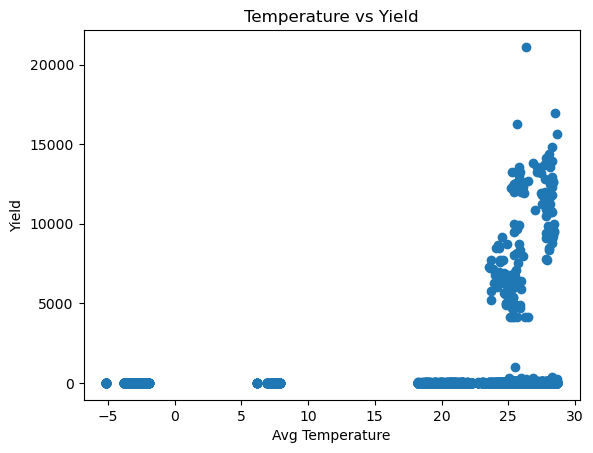

In [11]:
# tempareture impact of yield
plt.scatter(df["Avg_Temperature"], df["Yield"])
plt.xlabel("Avg Temperature")
plt.ylabel("Yield")
plt.title("Temperature vs Yield")
plt.show()

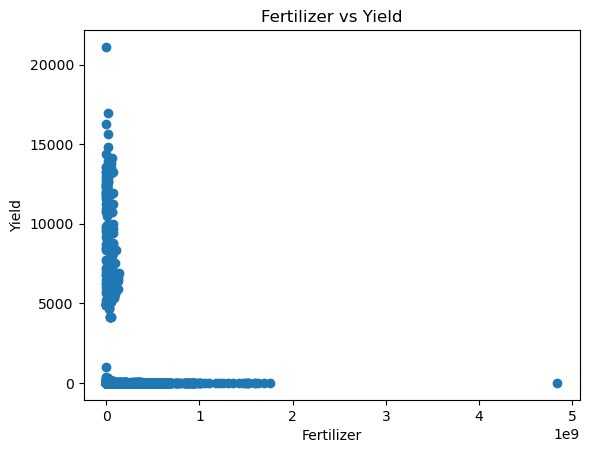

In [12]:
#fertilizer impact
plt.scatter(df["Fertilizer"], df["Yield"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

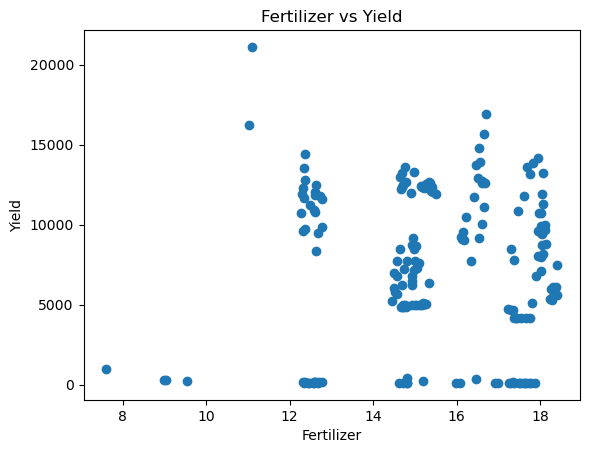

In [13]:
df = df[df["Fertilizer"] < 1e8] # removing extrme fertilzers
df = df[df["Yield"] > 100]  # removing zero yield rows
df["Fertilizer"] = np.log1p(df["Fertilizer"]) # logloss
#fertilizer impact
plt.scatter(df["Fertilizer"], df["Yield"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

In [14]:
df = df[df["Fertilizer"] < df["Fertilizer"].quantile(0.99)]

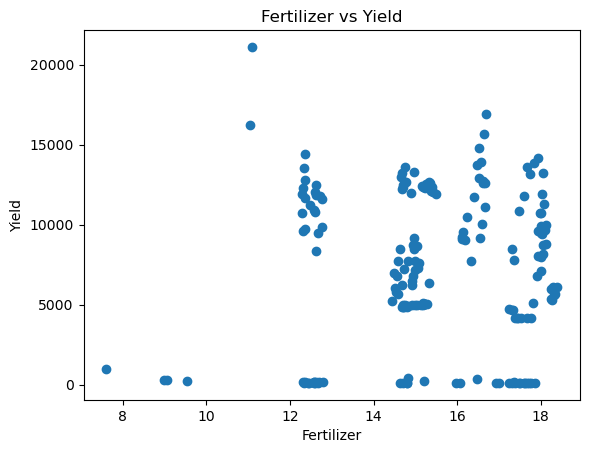

In [15]:
#fertilizer impact
plt.scatter(df["Fertilizer"], df["Yield"])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

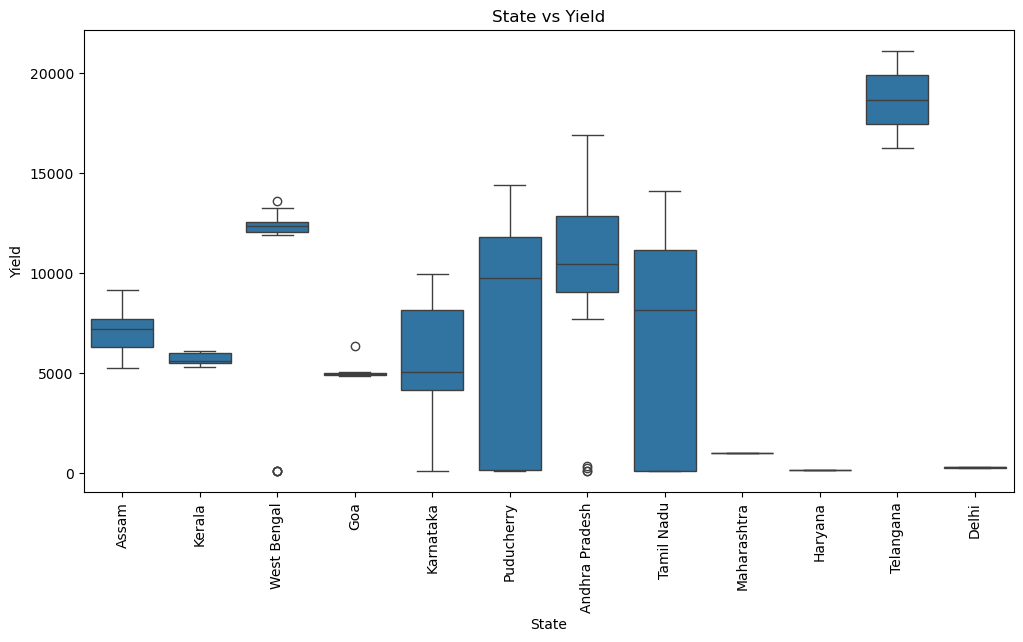

In [16]:
import seaborn as sns
# state wise yield
plt.figure(figsize=(12,6))
sns.boxplot(x="State", y="Yield", data=df)
plt.xticks(rotation=90)
plt.title("State vs Yield")
plt.show()

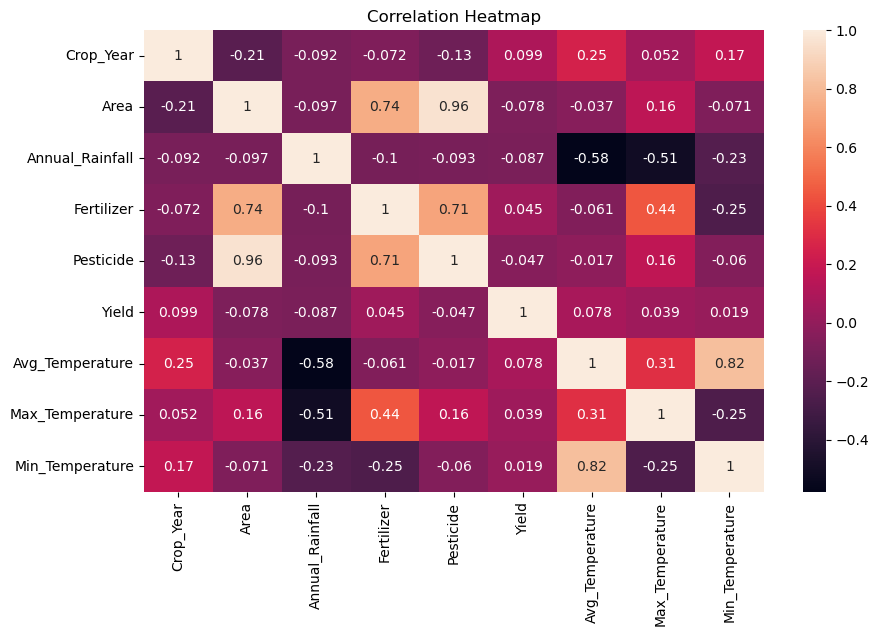

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
df.groupby("Crop")["Yield"].mean().sort_values()

Crop
Sugarcane     117.675967
Banana        121.305500
Onion         269.215333
Potato        290.670000
Cashewnut     338.549000
Maize         989.870000
Coconut      9371.194774
Name: Yield, dtype: float64

In [19]:
df.groupby("Crop")["Yield"].std().sort_values()

Crop
Banana          7.187740
Sugarcane      17.630504
Potato         35.229915
Onion         103.101440
Coconut      3406.277957
Cashewnut            NaN
Maize                NaN
Name: Yield, dtype: float64

In [20]:
print(df["Crop"].value_counts())

Crop
Coconut      146
Sugarcane     30
Onion          3
Potato         3
Banana         2
Cashewnut      1
Maize          1
Name: count, dtype: int64
